# $^{6}\mathrm{Li}$ estimations for the TRSA experiment at DHIPS

* this notebook estimate the self absorption at given temperatures and 
* the thicknesses of the absorption and scattering targets

## Initialzation

In [93]:
import warnings

import os
import sys
import numpy as np
from uncertainties import ufloat
sys.path.append("/home/kprifti/DHIPS2024/TRSA_on_Al27/analysis/ries")
import ries
from scipy.constants import physical_constants
from ries.constituents.element import Element, natural_elements
from ries.constituents.isotope import Isotope
from ries.constituents.state import GroundState, State
#from ries.resonance.voigt import Voigt
from ries.resonance.debye_model import effective_temperature_debye_approximation
import matplotlib.pyplot as plt
import numpy as np
from scipy.constants import physical_constants
from scipy.integrate import quad
from scipy.optimize import minimize
from scipy.stats import norm
from time import time

import arviz as az
import pandas as pd
from scipy.stats import truncnorm

In [94]:
from scipy.optimize import newton
from scipy.stats import cauchy, norm

from ries.resonance.maxwell_boltzmann import MaxwellBoltzmann
from ries.resonance.resonance import Resonance


class PseudoVoigtDistribution:
    """Class for a pseudo-Voigt distribution

    Approximates a Voigt distribution by a linear combination of a normal distribution and a
    Cauchy distribution instead of a convolution.
    For the mixing constant, an expression by Thompson *et al.* :cite:`Thompson1987` is used.

    Attributes:

    - `resonance_energy`, float, resonance energy, i.e. location of the centroid in MeV.
    - `maxwell_boltzmann`, `MaxwellBoltzmann` object, used to calculate the doppler width.
    - `Gamma_L_*`, `Gamma_G_*`, float, parameters used in the approximation of Thompson et al. in units of different powers of MeV.
    - `sigma`, float, standard deviation of the Doppler-broadened normal distribution in MeV.
    - `Gamma`, float, full width at half maximum (FWHM) of the normal distribution in MeV, used in the approximation of Thompson et al..
    - `gamma`, float, scale parameter of the Cauchy distribution.
    - `eta`, float, mixing parameter that controls the relative contributions of the normal- and the Cauchy distribution to the linear combination.
    """

    def __init__(self, resonance_energy, width, amu, effective_temperature):
        """Initialization

        Parameters:

        - `resonance_energy`, float, resonance energy, i.e. location of the centroid in MeV.
        - `width`, float, the width of the excited state in MeV.
        - `amu`, float, mass of the nucleus in atomic mass units.
        - `effective_temperature`, float, effective temperature of the ensemble of nuclei in K.
        """
        self.resonance_energy = resonance_energy
        self.maxwell_boltzmann = MaxwellBoltzmann(amu, effective_temperature)

        self.Gamma_L = width
        self.Gamma_L_squared = self.Gamma_L * self.Gamma_L
        self.Gamma_L_cubed = self.Gamma_L_squared * self.Gamma_L
        self.Gamma_L_squared_squared = self.Gamma_L_squared * self.Gamma_L_squared
        self.doppler_width = self.maxwell_boltzmann.get_doppler_width(
            self.resonance_energy
        )
        self.sigma = self.doppler_width / np.sqrt(2.0)
        self.Gamma_G = 2.0 * np.sqrt(np.log(2.0)) * self.doppler_width
        self.Gamma_G_squared = self.Gamma_G * self.Gamma_G
        self.Gamma_G_squared_squared = self.Gamma_G_squared * self.Gamma_G_squared

        self.Gamma = self.get_Gamma()
        self.eta = self.get_eta()
        self.gamma_G = self.Gamma / (2.0 * np.sqrt(np.log(2.0)))
        self.gamma_L = 0.5 * self.Gamma

        self.gamma = 0.5 * width

    def pseudo_voigt_expression(self, x, method):
        """Evaluate linear combination of normal- and Cauchy distribution

        To avoid repetitive code, this function replaces 'pdf', 'cdf', and 'ppf' in the general
        linear-combination expression.

        Parameters:

        - `x`, float or array_like, meaning depends on the `method` parameter, but it is most probably an energy in MeV (`method == 'pdf'` or `method == 'cdf'`)  or a quantile (`method == ppf`).
        - `method`, str, method of the distributions that should be called, for example 'pdf', 'cdf', or 'ppf'.

        Returns:

        - float or array_like, meaning depends on the `method` parameter, but it is most probably an energy in MeV (`method == 'ppf'`), a probability (`method == pdf`), or a quantile (`method == cdf`).
        """
        return eval(
            """(1.0 - self.eta) * norm.{}(
            x, loc=self.resonance_energy, scale=self.gamma_G / np.sqrt(2.0)
        ) + self.eta * cauchy.{}(
            x, loc=self.resonance_energy, scale=0.5 * self.gamma_L
        )""".format(
                method, method
            )
        )

    def cdf(self, E):
        """CDF of the pseudo-Voigt distribution

        Parameters:

        - `E`, float or array_like, energy in MeV.

        Returns:

        float or array_like, CDF
        """
        return self.pseudo_voigt_expression(E, "cdf")

    def pdf(self, E):
        """PDF of the pseudo-Voigt distribution

        Parameters:

        - `E`, float or array_like, energy in MeV.

        Returns:

        float or array_like, PDF
        """
        return self.pseudo_voigt_expression(E, "pdf")

    def ppf(self, quantile):
        """PPF of the pseudo-Voigt distribution

        This function tries to invert the pseudo-Voigt CDF numerically first.
        If the root-finding algorithm does not converge for any of the given quantiles, the
        RuntimeError issued by the algorithm is caught and a fallback approximation is used which
        is based on a linear combination of PPFs.

        Parameters:

        - `quantile`, float or array_like, quantile.

        Returns:

        float or array_like, PPF
        """

        try:
            # scipy.optimize.newton returns different output depending on whether quantile is a
            # scalar or an array.
            # For a scalar, the root is `newton_result[0]` and the flag that indicates whether
            # the algorithm converged is `newton_result[1]`.converged`.
            # In the case of an array, it is `newton_result[0]` and `newton_result[1]`.
            newton_result = newton(
                lambda E: self.pseudo_voigt_expression(E, "cdf") - quantile,
                # Use resonance energy as start value.
                # There are closer guesses for an arbitrary q, but starting at the resonance
                # energy ensures that the algorithm does not have rounding errors from the start
                # which might cause it to go in the wrong direction.
                self.resonance_energy
                if isinstance(quantile, (float, int))
                else self.resonance_energy * np.ones(len(quantile)),
                fprime=lambda E: self.pseudo_voigt_expression(E, "pdf"),
                full_output=True,
            )
            if isinstance(quantile, (int, float)):
                if newton_result[1].converged:
                    return newton_result[0]
            elif False not in newton_result[1]:
                return newton_result[0]

        except RuntimeError:
            warnings.warn(
                "Calculation of pseudo-Voigt PPF by numerical inversion of the CDF failed for at least one value. Using approximation instead.",
                UserWarning,
            )
            return self.pseudo_voigt_expression(quantile, "ppf")

    def get_Gamma(self):
        """Calculate Gamma parameter

        This parameter is used internally in the approximation of Thompson et al..
        """
        return (
            self.Gamma_G_squared_squared * self.Gamma_G
            + 2.69269 * self.Gamma_G_squared_squared * self.Gamma_L
            + 2.42843 * self.Gamma_G_squared * self.Gamma_G * self.Gamma_L_squared
            + 4.47163 * self.Gamma_G_squared * self.Gamma_L_cubed
            + 0.07842 * self.Gamma_G * self.Gamma_L_squared_squared
            + self.Gamma_L_squared_squared * self.Gamma_L
        ) ** 0.2

    def get_eta(self):
        """Calculate mixing parameter"""
        inverse_Gamma = 1.0 / self.Gamma
        inverse_Gamma_squared = inverse_Gamma * inverse_Gamma
        return (
            1.36603 * self.Gamma_L * inverse_Gamma
            - 0.47719 * self.Gamma_L_squared * inverse_Gamma_squared
            + 0.11116 * self.Gamma_L_cubed * inverse_Gamma_squared * inverse_Gamma
        )


class PseudoVoigt(Resonance):
    r"""Approximation for a Doppler-broadened Breit-Wigner cross section (pseudo-Voigt profile)

    See `ries.resonance.resonance.Resonance`.
    """

    def __init__(
        self,
        initial_state,
        intermediate_state,
        amu,
        effective_temperature,
        final_state=None,
    ):
        r"""Initialization

        Parameters:

        - `amu`, float, mass of the nucleus in atomic mass units.
        - `effective_temperature`, float, effective temperature of the ensemble of nuclei in K.

        See also `ries.resonance.resonance.Resonance`.
        """
        Resonance.__init__(self, initial_state, intermediate_state, final_state)

        self.probability_distribution = PseudoVoigtDistribution(
            self.resonance_energy,
            self.intermediate_state.width,
            amu,
            effective_temperature,
        )
        self.probability_distribution_parameters = ()


In [95]:
from scipy.special import voigt_profile

class SemiPseudoVoigtDistribution(PseudoVoigtDistribution):
    """Class for a Voigt distribution, using pseudo-Voigt expressions for CDF and PPF

    The `pdf()` method calls `scipy.special.voigt_profile`, while the CDF and the PPF are approximated
    by a pseudo-Voigt distribution (see `ries.resonance.pseudo_voigt`).

    See also `ries.resonance.pseudo_voigt.PseudoVoigtDistribution`.
    """

    def pdf(self, E):
        """PDF of Voigt distribution

        Wraps `scipy.special.voigt_profile`.

        Parameter

        - `E`, float or array_like, energy of the incident beam particle in MeV.

        Returns:

        - float or array_like, PDF
        """
        return voigt_profile(E - self.resonance_energy, self.sigma, self.gamma)


class Voigt(PseudoVoigt):
    r"""Class for a Doppler-broadened Breit-Wigner cross section (Voigt profile)

    See `ries.resonance.resonance.Resonance`.
    """

    def __init__(
        self,
        initial_state,
        intermediate_state,
        amu,
        effective_temperature,
        final_state=None,
    ):
        r"""Initialization

        Parameters:

        - `amu`, float, mass of the nucleus in atomic mass units.
        - `effective_temperature`, float, effective temperature of the ensemble of nuclei in K.

        See also `ries.resonance.resonance.Resonance`.
        """
        PseudoVoigt.__init__(
            self,
            initial_state,
            intermediate_state,
            amu,
            effective_temperature,
            final_state,
        )

        self.probability_distribution = SemiPseudoVoigtDistribution(
            self.resonance_energy,
            self.intermediate_state.width,
            amu,
            effective_temperature,
        )


In [96]:
li6 = Isotope(X="6Li",
        Z=2,
        A=6,
        amu=natural_elements[3].isotopes[6].amu,
        ground_state=GroundState("1^+_1", two_J=2, parity=1),
        excited_states={
            "0^+_1": State(
                "0^+_1", two_J=0, parity=1, 
                excitation_energy=3.56288,
                partial_widths={"1^+_1": 8.17e-6}
            )
        }
       )

## Intro: $N_\mathrm{\gamma} \cdot \varepsilon_\mathrm{abs}$ from TRSA measurement on $\mathrm{^{27}Al}$

Peak volume:

$$
A(E_\mathrm{\gamma}) = I_\mathrm{0\rightarrow i \rightarrow 0} \cdot W_\mathrm{0\rightarrow i \rightarrow 0}(\theta, \phi) \cdot N_\mathrm{T} \cdot (N_\mathrm{\gamma}(E_\mathrm{i}) \cdot \varepsilon_\mathrm{abs}(E_\mathrm{\gamma}))
$$

* $N_T$: the number of target nuclei irradiated by the photon beam

$$
N_T = \frac{m_\mathrm{target}\cdot N_\mathrm{Av}}{\mu} 
$$

* $M_\mathrm{target}$: is the mass of the target
* $\mu$: is the molar mass of aluminum (26.98 g/mol)

* $I_\mathrm{0\rightarrow i \rightarrow 0}$: integrated cross section 

$$
I_\mathrm{0\rightarrow i \rightarrow 0} = \pi^2 \cdot (\frac{\hbar c}{E_\mathrm{i}})^2 \cdot (\frac{2J_i+1}{2J_0+1})\cdot\Gamma_0\cdot\frac{\Gamma_0}{\Gamma}
$$

* $\Gamma_0$ i the ground-state decay width
* $\frac{\Gamma_0}{\Gamma}$ is the branching ratio to the ground state

Then the peak volume can be written as:

$$
A(E_\mathrm{\gamma}) = (\pi^2 \cdot (\frac{\hbar c}{E_\mathrm{i}})^2 \cdot (\frac{2J_i+1}{2J_0+1})\cdot\Gamma_0\cdot\frac{\Gamma_0}{\Gamma}) \cdot W_\mathrm{0\rightarrow i \rightarrow 0}(\theta, \phi) \cdot N_\mathrm{T} \cdot (N_\mathrm{\gamma}(E_\mathrm{i}) \cdot \varepsilon_\mathrm{abs}(E_\mathrm{\gamma}))
$$

$$
N_\mathrm{\gamma}(E_\mathrm{i}) \cdot \varepsilon_\mathrm{abs}(E_\mathrm{\gamma}) = \frac{A(E_\mathrm{\gamma})}{(\pi^2 \cdot (\frac{\hbar c}{E_\mathrm{i}})^2 \cdot (\frac{2J_i+1}{2J_0+1})\cdot\Gamma_0\cdot\frac{\Gamma_0}{\Gamma}) \cdot W_\mathrm{0\rightarrow i \rightarrow 0}(\theta, \phi) \cdot N_\mathrm{T}}
$$

In [97]:
peakVol_HPGe2 = ufloat(10407.970728415468, 116.54371597210691) # counts, taken from TRSA measurement on 27Al peak at 3.9568 MeV
peakVol_HPGePol = ufloat(4971.847816526843, 83.32256508517725) # counts, taken from TRSA measurement on 27Al peak at 3.9568 MeV
GSDecayWidth_27Al = ufloat(158.88, 5.06) # meV, taken from results of TRSA measurement on 27Al peak at 3.9568 MeV
GSBranchingRation_27Al = 1 + ((ufloat(6.6, 1.7) + ufloat(4.3, 1.4) + ufloat(5.3, 1.7)) / 100) / (ufloat(100.0, 2.3) / 100)
J0 = 5/2 # taken from Nudat
Ji = 3/2 # taken from Nudat
Ei_27Al = 3.9568 # MeV
duration_NRF = 168.4306 # hours
mass_sc = ufloat(15.082, 0.0050) # g
molar_mass_27Al = ufloat(26.9815385, 0.000001) # g/mol
NA = physical_constants["Avogadro constant"][0] # 1/mol
hbar_c = physical_constants["reduced Planck constant times c in MeV fm"][0]

In [98]:
def NT_solid(mass, molar_mass):
 """ Calculate the number of target nuclei in a solid target.
     Parameters:
     mass: in g
     molar_mass: in g/mol
     NA: Avogadro's number in 1/mol

     Returns:
     number of target nuclei, dimensionless
 """
 return (mass / molar_mass) * NA

number_target_nuclei_27Al = NT_solid(mass_sc, molar_mass_27Al) # dimensionless
print(f"Number of target nuclei: {number_target_nuclei_27Al}, relative Unc: {number_target_nuclei_27Al.s / number_target_nuclei_27Al.n:.2%}")


Number of target nuclei: (3.3662+/-0.0011)e+23, relative Unc: 0.03%


In [99]:
def integrated_cross_section(J0, Ji, Ei, Gamma_0, Br):
    """Calculate the integrated cross section for a resonance

    Parameters:

    - `J0`, float, spin of the initial state.
    - `Ji`, float, spin of the intermediate state.
    - `Ei`, float, resonance energy in MeV.
    - `Gamma_0`, ufloat, partial width for the decay to the initial state in eV.
    - `Br`, ufloat, branching ratio for the decay to the final state, dimensionless.

    Returns:

    - float, integrated cross section in eV*fm^2
    """
    return np.pi** 2 * (2 * Ji + 1) / (2 * J0 + 1) * (hbar_c / Ei) ** 2 * Gamma_0 * Br

millieV_to_eV = 1e-3
integrated_cross_section_27Al_eV_fm2 = integrated_cross_section(J0, Ji, Ei_27Al, GSDecayWidth_27Al * millieV_to_eV, GSBranchingRation_27Al)
print(f"Integrated cross section: {integrated_cross_section_27Al_eV_fm2} eV*fm^2, relative Unc: {integrated_cross_section_27Al_eV_fm2.s / integrated_cross_section_27Al_eV_fm2.n:.2%}")
fm2_to_cm2 = 1e-26
integrated_cross_section_27Al_eV_cm2 = integrated_cross_section_27Al_eV_fm2 * fm2_to_cm2
print(f"Integrated cross section: {integrated_cross_section_27Al_eV_cm2} cm^2*eV, relative Unc: {integrated_cross_section_27Al_eV_cm2.s / integrated_cross_section_27Al_eV_cm2.n:.2%}")

Integrated cross section: (3.02+/-0.12)e+03 eV*fm^2, relative Unc: 4.00%
Integrated cross section: (3.02+/-0.12)e-23 cm^2*eV, relative Unc: 4.00%


In [100]:
def calculate_N_gamma_epsilon_abs(peakVol, Ics, NT, duration):
 """Calculate the product of the number of incident photons and the absolute efficiency of the detector
 
 Parameters:
 - `peakVol`, ufloat, peak area in counts.
 - `Ics`, ufloat, integrated cross section in cm^2*eV.
 - `NT`, ufloat, number of target nuclei, dimensionless. 
 - `duration`, float, duration of the measurement in hours.
 Returns:
 - float, product of the number of incident photons and the absolute efficiency of the detector, photons cm^{-2} eV^{-1} sec^{-1}.
 """
 return peakVol / (Ics * NT * duration * 3600)

N_gamma_eff_HPGe2 = calculate_N_gamma_epsilon_abs(peakVol_HPGe2, integrated_cross_section_27Al_eV_cm2, number_target_nuclei_27Al, duration_NRF)
print(f"N_gamma * epsilon_abs (HPGe2): {N_gamma_eff_HPGe2} photons cm^-2 eV^-1 sec^-1, relative Unc: {N_gamma_eff_HPGe2.s / N_gamma_eff_HPGe2.n:.2%}")

N_gamma_eff_HPGePol = calculate_N_gamma_epsilon_abs(peakVol_HPGePol, integrated_cross_section_27Al_eV_cm2, number_target_nuclei_27Al, duration_NRF)
print(f"N_gamma * epsilon_abs (HPGePol): {N_gamma_eff_HPGePol} photons cm^-2 eV^-1 sec^-1, relative Unc: {N_gamma_eff_HPGePol.s / N_gamma_eff_HPGePol.n:.2%}")

N_gamma * epsilon_abs (HPGe2): 0.00169+/-0.00007 photons cm^-2 eV^-1 sec^-1, relative Unc: 4.15%
N_gamma * epsilon_abs (HPGePol): 0.000806+/-0.000035 photons cm^-2 eV^-1 sec^-1, relative Unc: 4.33%


# Part I: Estimation peak counts for NRF measurement on $\mathrm{^{6}Li}$

In [101]:
GSDecayWidth_6Li = ufloat(8.17, 0.17) # eV
GSBranchingRation_6Li = 1 
J0 = 1
Ji = 0
li6_enrichment = ufloat(0.9500, 0.0001)
li6_scatterer_mass = ufloat(5.033, 0.005)  # in g


def molar_mass(enrichment):
    # li6.amu returns in u, multiply by 1 g/mol per u
    return (
        2.0 * (enrichment * li6.amu + (1.0 - enrichment) * natural_elements[3].isotopes[7].amu) +
        natural_elements[6].amu() + 3 * natural_elements[8].amu()
    )
# ensure that natural_elements[6].amu() returns g/mol

molar_mass_li6_carbonate = molar_mass(li6_enrichment)

def NT_compound(mass, molar_mass, enrichment):
    return (mass / molar_mass) * NA * enrichment * 2
molar_mass_li6_carbonate = molar_mass(li6_enrichment) # in g/mol

molar_mass_li6_carbonate

72.13936252210557+/-0.00020017610936799992

For a compund the number of target nuclei of a specific isotope is:

$$
N_T = \frac{m_\mathrm{target}\cdot N_\mathrm{Av}\cdot n_\mathrm{element} \cdot \alpha}{\mu_\mathrm{compound}} 
$$

* $n_\mathrm{element}$: number of atoms of thet element per molecule
* $\alpha$: isotopic enrichment

In [102]:
def NT_compound(mass, molar_mass, enrichment):
    """Calculate the number of 6Li target nuclei in a solid target.

    Parameters:
    - `mass`, ufloat, mass of the target in g.
    - `molar_mass`, ufloat, molar mass of the target in g/mol.
    - `enrichment`, ufloat, isotopic enrichment of 6Li, dimensionless.

    Returns:
    - float, number of 6Li target nuclei, dimensionless.
    """
    return (mass / molar_mass) * NA * enrichment * 2

NT_compound_carbonate = NT_compound(li6_scatterer_mass, molar_mass_li6_carbonate, li6_enrichment)
print(f"Number of 6Li target nuclei: {NT_compound_carbonate}, relative Unc: {NT_compound_carbonate.s / NT_compound_carbonate.n:.2%}")

Number of 6Li target nuclei: (7.983+/-0.008)e+22, relative Unc: 0.10%


In [103]:
integrated_cross_section_6Li_eV_fm2 = integrated_cross_section(J0, Ji, li6.excited_states["0^+_1"].excitation_energy, GSDecayWidth_6Li, GSBranchingRation_6Li)
integrated_cross_section_6Li_eV_fm2
integrated_cross_section_6Li_eV_cm2 = integrated_cross_section_6Li_eV_fm2 * fm2_to_cm2
print(f"Integrated cross section for 6Li: {integrated_cross_section_6Li_eV_cm2} cm^2*eV, relative Unc: {integrated_cross_section_6Li_eV_cm2.s / integrated_cross_section_6Li_eV_cm2.n:.2%}")

Integrated cross section for 6Li: (8.24+/-0.17)e-22 cm^2*eV, relative Unc: 2.08%


In [104]:
def calculate_peak_counts(N_gamma_eff, Ics, NT):
    """Calculate the expected peak counts for a NRF measurement on 6Li

    Parameters:
    - `N_gamma_eff`, ufloat, product of the number of incident photons and the absolute efficiency of the detector in photons cm^{-2} eV^{-1} sec^{-1}.
    - `Ics`, ufloat, integrated cross section in cm^2*eV.
    - `NT`, ufloat, number of target nuclei, dimensionless. 

 
    """
    return N_gamma_eff * Ics * NT

expected_peak_counts_HPGe2 = calculate_peak_counts(N_gamma_eff_HPGe2, integrated_cross_section_6Li_eV_cm2, NT_compound_carbonate)
print(f"Expected peak counts for HPGe2: {expected_peak_counts_HPGe2} photons per second, relative Unc: {expected_peak_counts_HPGe2.s / expected_peak_counts_HPGe2.n:.2%}")
expected_peak_counts_HPGePol = calculate_peak_counts(N_gamma_eff_HPGePol, integrated_cross_section_6Li_eV_cm2, NT_compound_carbonate)
print(f"Expected peak counts for HPGePol: {expected_peak_counts_HPGePol} photons per second, relative Unc: {expected_peak_counts_HPGePol.s / expected_peak_counts_HPGePol.n:.2%}")

Expected peak counts for HPGe2: 0.111+/-0.005 photons per second, relative Unc: 4.64%
Expected peak counts for HPGePol: 0.0531+/-0.0026 photons per second, relative Unc: 4.81%


In [105]:
duration_days = 5.1
duration_NRF_li6 = duration_days * 24 * 3600 # in seconds
expected_peak_counts_HPGe2_total = expected_peak_counts_HPGe2 * duration_NRF_li6
print(f"Expected total peak counts for HPGe2 after {duration_days} days: {expected_peak_counts_HPGe2_total}, relative Unc: {expected_peak_counts_HPGe2_total.s / expected_peak_counts_HPGe2_total.n:.2%}") 
expected_peak_counts_HPGePol_total = expected_peak_counts_HPGePol * duration_NRF_li6
print(f"Expected total peak counts for HPGePol after {duration_days} days: { expected_peak_counts_HPGePol_total}, relative Unc: {expected_peak_counts_HPGePol_total.s / expected_peak_counts_HPGePol_total.n:.2%}")

Expected total peak counts for HPGe2 after 5.1 days: (4.89+/-0.23)e+04, relative Unc: 4.64%
Expected total peak counts for HPGePol after 5.1 days: (2.34+/-0.11)e+04, relative Unc: 4.81%


In [106]:
print(f"Expected peak counts after and hour for HPGe2: {expected_peak_counts_HPGe2 * 3600}, relative Unc: {(expected_peak_counts_HPGe2 * 3600).s / (expected_peak_counts_HPGe2 * 3600).n:.2%}")
print(f"Expected peak counts after and hour for HPGePol: {expected_peak_counts_HPGePol * 3600}, relative Unc: {(expected_peak_counts_HPGePol * 3600).s / (expected_peak_counts_HPGePol * 3600).n:.2%}")

Expected peak counts after and hour for HPGe2: 400+/-19, relative Unc: 4.64%
Expected peak counts after and hour for HPGePol: 191+/-9, relative Unc: 4.81%


In [107]:
total_expected_peak_counts = expected_peak_counts_HPGe2_total + expected_peak_counts_HPGePol_total
print(f"Expected total peak counts from both detectors after {duration_days} days: {expected_peak_counts_HPGe2_total + expected_peak_counts_HPGePol_total}, relative Unc: {(expected_peak_counts_HPGe2_total + expected_peak_counts_HPGePol_total).s / (expected_peak_counts_HPGe2_total + expected_peak_counts_HPGePol_total).n:.2%}")

Expected total peak counts from both detectors after 5.1 days: (7.23+/-0.33)e+04, relative Unc: 4.60%


In [108]:
(total_expected_peak_counts.s/total_expected_peak_counts.n) * 100

4.602879174222871

In [16]:
R_exp = ufloat(0.5192, 0.00020) # measured self-absorption from RSA measurement on 6Li peak at 3.56288 MeV, taken from U. Friman-Gayer et al., Phys. Rev. Lett. 126, 102501 (2021)

In [22]:
'''
R_mu = R_exp.n
R_sigma = R_exp.s
ref_duration_s = duration_NRF_li6  # reference duration that produced N0 (in seconds)

chain_count = 4
draws_per_chain = 10000
hdi_prob = 0.681

def draw_truncated_normal(mu, sigma, lower, upper, size, random_generator):
    if sigma <= 0:
        return np.full(size, mu, dtype=float)
    a = (lower - mu) / sigma
    b = (upper - mu) / sigma
    return truncnorm.rvs(a, b, loc=mu, scale=sigma, size=size, random_state=random_generator)

# This cell only propagates prior uncertainty through deterministic formulas, so direct Monte Carlo draws are much faster than running MCMC.
N0_samples = draw_truncated_normal(total_expected_peak_counts.n, total_expected_peak_counts.s, lower=0.0, upper=np.inf, size=(chain_count, draws_per_chain), random_generator=np.random.default_rng(42))
R_samples = draw_truncated_normal(R_mu, R_sigma, lower=0.0, upper=1.0, size=(chain_count, draws_per_chain), random_generator=np.random.default_rng(42))

attenuation_samples = 1.0 - R_samples
N_with_samples = N0_samples * attenuation_samples
rate_with_samples = N_with_samples / ref_duration_s
duration_needed_samples = total_expected_peak_counts.n / rate_with_samples

trace = az.from_dict(posterior={"N0_pos": N0_samples, "attenuation": attenuation_samples, "N_with": N_with_samples, "rate_with_per_s": rate_with_samples, "duration_needed_s": duration_needed_samples})

summary = az.summary( trace, var_names=["N_with", "rate_with_per_s", "duration_needed_s", "attenuation", "N0_pos"], hdi_prob=hdi_prob)
print(summary)

# Extract Monte Carlo samples
posterior_N_with = trace.posterior["N_with"].values.flatten()
posterior_rate_with = trace.posterior["rate_with_per_s"].values.flatten()
posterior_duration_s = trace.posterior["duration_needed_s"].values.flatten()
posterior_duration_days = posterior_duration_s / 3600 / 24

# HDIs and medians
N_with_hdi = az.hdi(posterior_N_with, hdi_prob=hdi_prob)
rate_with_hdi = az.hdi(posterior_rate_with, hdi_prob=hdi_prob)
duration_hdi_days = az.hdi(posterior_duration_days, hdi_prob=hdi_prob)

results_table = pd.DataFrame([{"quantity": f"Expected counts with absorber ({duration_days} d)", "median": np.median(posterior_N_with), "hdi_lower": N_with_hdi[0], "hdi_upper": N_with_hdi[1], "unit": "counts"}, {"quantity": "Rate with absorber", "median": np.median(posterior_rate_with), "hdi_lower": rate_with_hdi[0], "hdi_upper": rate_with_hdi[1], "unit": "counts/s"}, {"quantity": f"Duration for {total_expected_peak_counts.n:.0f} counts", "median": np.median(posterior_duration_days), "hdi_lower": duration_hdi_days[0], "hdi_upper": duration_hdi_days[1], "unit": "days"}]).set_index("quantity")

print(f"\n--- Results ({int(hdi_prob * 100)}% HDI) ---")
print(results_table.to_string(
        formatters={
            "median": lambda value: f"{value:.4f}" if value < 100 else f"{value:.0f}",
            "hdi_lower": lambda value: f"{value:.4f}" if value < 100 else f"{value:.0f}",
            "hdi_upper": lambda value: f"{value:.4f}" if value < 100 else f"{value:.0f}"}))
'''

'\nR_mu = R_exp.n\nR_sigma = R_exp.s\nref_duration_s = duration_NRF_li6  # reference duration that produced N0 (in seconds)\n\nchain_count = 4\ndraws_per_chain = 10000\nhdi_prob = 0.681\n\ndef draw_truncated_normal(mu, sigma, lower, upper, size, random_generator):\n    if sigma <= 0:\n        return np.full(size, mu, dtype=float)\n    a = (lower - mu) / sigma\n    b = (upper - mu) / sigma\n    return truncnorm.rvs(a, b, loc=mu, scale=sigma, size=size, random_state=random_generator)\n\n# This cell only propagates prior uncertainty through deterministic formulas, so direct Monte Carlo draws are much faster than running MCMC.\nN0_samples = draw_truncated_normal(total_expected_peak_counts.n, total_expected_peak_counts.s, lower=0.0, upper=np.inf, size=(chain_count, draws_per_chain), random_generator=np.random.default_rng(42))\nR_samples = draw_truncated_normal(R_mu, R_sigma, lower=0.0, upper=1.0, size=(chain_count, draws_per_chain), random_generator=np.random.default_rng(42))\n\nattenuation

In [17]:
# Sampling directly from the experimental definition:
# Rexp = 1 - N_with_absorber / N_without_absorber

R_mu = R_exp.n
R_sigma = R_exp.s
ref_duration_s = duration_NRF_li6  # reference duration that produced N0 (in seconds)

chain_count = 4
draws_per_chain = 10000
hdi_prob = 0.681
sample_shape = (chain_count, draws_per_chain)
rng = np.random.default_rng(123)

def draw_truncated_normal(mu, sigma, lower, upper, size, random_generator):
    if sigma <= 0:
        return np.full(size, mu, dtype=float)
    a = (lower - mu) / sigma
    b = (upper - mu) / sigma
    return truncnorm.rvs(a, b, loc=mu, scale=sigma, size=size, random_state=random_generator)


N_without_absorber_samples = draw_truncated_normal(total_expected_peak_counts.n, total_expected_peak_counts.s, lower=0.0, upper=np.inf, size=sample_shape, random_generator=rng)
Rexp_samples = draw_truncated_normal(R_exp.n, R_exp.s, lower=0.0, upper=1.0, size=sample_shape, random_generator=rng)

attenuation_factor_samples = 1.0 - Rexp_samples
N_with_absorber_samples = N_without_absorber_samples * attenuation_factor_samples
rate_with_absorber_samples = N_with_absorber_samples / ref_duration_s

# This is the time needed to recover, for each draw, the same counts as the
# corresponding sampled no-absorber case.
duration_for_equal_statistics_s = N_without_absorber_samples / rate_with_absorber_samples
duration_for_equal_statistics_days = duration_for_equal_statistics_s / 3600 / 24

N_with_absorber_hdi = az.hdi(N_with_absorber_samples.reshape(-1), hdi_prob=hdi_prob)
rate_with_absorber_hdi = az.hdi(rate_with_absorber_samples.reshape(-1), hdi_prob=hdi_prob)
duration_equal_stats_hdi = az.hdi(duration_for_equal_statistics_days.reshape(-1), hdi_prob=hdi_prob)

In [18]:
results_from_Rexp_table = pd.DataFrame(
    [
        {
            "Quantity": f"N_with_absorber ({duration_days} d)",
            "Median": np.median(N_with_absorber_samples),
            f"{hdi_prob:.1%} HDI": f"[{N_with_absorber_hdi[0]:.0f}, {N_with_absorber_hdi[1]:.0f}]",
            "Unit": "counts",
        },
        {
            "Quantity": "Rate with absorber",
            "Median": np.median(rate_with_absorber_samples),
            f"{hdi_prob:.1%} HDI": f"[{rate_with_absorber_hdi[0]:.4f}, {rate_with_absorber_hdi[1]:.4f}]",
            "Unit": "counts/s",
        },
        {
            "Quantity": "Duration for equal statistics",
            "Median": np.median(duration_for_equal_statistics_days),
            f"{hdi_prob:.1%} HDI": f"[{duration_equal_stats_hdi[0]:.4f}, {duration_equal_stats_hdi[1]:.4f}]",
            "Unit": "days",
        },
    ]
)

results_from_Rexp_table["Median"] = [
    f"{results_from_Rexp_table.loc[0, 'Median']:.0f}",
    f"{results_from_Rexp_table.loc[1, 'Median']:.4f}",
    f"{results_from_Rexp_table.loc[2, 'Median']:.4f}",
]

print(f"Results sampled from Rexp = 1 - N_with_absorber / N_without_absorber ({hdi_prob:.1%} HDI)")
display(results_from_Rexp_table)

Results sampled from Rexp = 1 - N_with_absorber / N_without_absorber (68.1% HDI)


,Quantity,Median,68.1% HDI,Unit
0,N_with_absorber (5.1 d),34778,"[33149, 36323]",counts
1,Rate with absorber,0.0789,"[0.0752, 0.0824]",counts/s
2,Duration for equal statistics,10.6073,"[10.6030, 10.6118]",days


# Part II: Estimate self-absorption precision 

In [19]:
Tmeas=[77.7, 600] # in K
Debye_temperature = 448  # in K. https://www.knowledgedoor.com/2/elements_handbook/debye_temperature.ht ml

# From De
Teff = {}
for t in Tmeas:
 teff=effective_temperature_debye_approximation(t, Debye_temperature)
 Teff[t] = teff
Teff

{77.7: array(174.63086186), 600: array(616.61545982)}

In [20]:
def areal_density(mass, diameter, enrichment):
    """Calculate the areal density of a cylindrical, 6Li-enriched, lithium carbonate sample
       Areal density in fm^2.
    """
    return (2.*enrichment*mass/(molar_mass(enrichment) *physical_constants["atomic mass constant"][0] *np.pi*(0.5*diameter*1e15)**2))

def photon_flux_density(sigma, energy, rho):
    """    Dimensionless photon-flux density    """
    return np.exp(-sigma(energy, input_is_absolute_energy=False)*rho)

def resonance_absorption_density(sigma, energy, rho):
    """    Resonance-absorption density in fm^2   """
    return sigma(energy, input_is_absolute_energy=False)*photon_flux_density(sigma, energy, rho)

In [21]:
def R_2D(Gamma, theta_D, T_meas, absorber_mass, scatterer_mass, diameter, enrichment, energy_coverage_interval=0.999):
    """
    Self-absorption as a function of Gamma and Debye temperature.
    
    Parameters:
        Gamma: partial width in MeV
        theta_D: Debye temperature in K
        T_meas: measurement temperature of the scatterer in K
        absorber_mass, scatterer_mass, diameter, enrichment: target parameters for the areal density calculation should be in units of kg and m
    """
    T_eff_with_absorber = effective_temperature_debye_approximation(T_meas, theta_D)
    T_eff_without_absorber = effective_temperature_debye_approximation(320., theta_D) 
    
    # In the self-absorption measurement the absorbing and scattering target were at the same temperature Tmeas
    sigma_with_absorber = Voigt(initial_state=GroundState("1^+_1", two_J=2, parity=1), intermediate_state=State("0^+_1", two_J=0, parity=1, excitation_energy=3.56288, partial_widths={"1^+_1": Gamma}), amu=natural_elements[3].isotopes[6].amu, effective_temperature=T_eff_with_absorber)
    
    # In the measurement without the absorbing target the scattering target is considered at T=320 K cloe to the room temperature
    sigma_without_absorber = Voigt(initial_state=GroundState("1^+_1", two_J=2, parity=1), intermediate_state=State("0^+_1", two_J=0, parity=1, excitation_energy=3.56288, partial_widths={"1^+_1": Gamma}), amu=natural_elements[3].isotopes[6].amu, effective_temperature=T_eff_without_absorber)
    
    rho_abs = areal_density(absorber_mass, diameter, enrichment)
    rho_scat = areal_density(scatterer_mass, diameter, enrichment)
    
    energy_limits = sigma_with_absorber.coverage_interval(energy_coverage_interval) - sigma_with_absorber.intermediate_state.excitation_energy
    energy_limits_without_absorber = sigma_without_absorber.coverage_interval(energy_coverage_interval) - sigma_without_absorber.intermediate_state.excitation_energy
    
    numerator = quad(lambda energy: (np.exp(-sigma_with_absorber(energy, input_is_absolute_energy=False) * rho_abs)* (1. - np.exp(-sigma_with_absorber(energy, input_is_absolute_energy=False) * rho_scat)) ), *energy_limits)[0]
    
    denominator = quad(lambda energy: (1. - np.exp(-sigma_without_absorber(energy, input_is_absolute_energy=False) * rho_scat) ), *energy_limits_without_absorber)[0]
    
    return 1. - numerator / denominator

Gamma_range = np.linspace(1.35300000e-06, 8.98700000e-06, 50)   # ±10%
theta_D_range = np.linspace(100, 800, 50)  # ±15%

In [22]:
g_to_kg = 1e-3
cm_to_m = 1e-2
li6_absorber_mass = ufloat(8.000, 0.005) # in g
target_diameter = ufloat(2.000, 0.005) # in cm

In [23]:
R_self_absorption_TRSA_6Li = {}
for T_meas in Tmeas:
 R_self_absorption_TRSA_6Li[T_meas] = R_2D(
  Gamma=GSDecayWidth_6Li.n * 1e-6,  # Convert from eV to MeV
  theta_D=Debye_temperature,
  T_meas=T_meas,
  absorber_mass=li6_absorber_mass.n * g_to_kg,
  scatterer_mass=li6_scatterer_mass.n * g_to_kg,
  diameter=target_diameter.n * cm_to_m,
  enrichment=li6_enrichment.n
 )
 print(f"Self-absorption at T_meas = {T_meas} K: R = {R_self_absorption_TRSA_6Li[T_meas]:.4f}")

Self-absorption at T_meas = 77.7 K: R = 0.4988
Self-absorption at T_meas = 600 K: R = 0.3824


In [24]:
for T_meas in Tmeas:
 print(f"If the mass of the absorber is {li6_absorber_mass} g, the expected self-absorption at T_meas = {T_meas} K is R = {R_self_absorption_TRSA_6Li[T_meas]:.4f}.")

If the mass of the absorber is 8.000+/-0.005 g, the expected self-absorption at T_meas = 77.7 K is R = 0.4988.
If the mass of the absorber is 8.000+/-0.005 g, the expected self-absorption at T_meas = 600 K is R = 0.3824.


In [25]:
# Compute R_2D on the (Gamma_range, theta_D_range) grid for each measurement temperature
R_grid_TRSA_6Li = {}
for T_meas_val in Tmeas:
    grid = np.zeros((len(theta_D_range), len(Gamma_range)))
    for i, theta_D in enumerate(theta_D_range):
        for j, Gamma in enumerate(Gamma_range):
            grid[i, j] = R_2D(
                Gamma=Gamma,
                theta_D=theta_D,
                T_meas=T_meas_val,
                absorber_mass=li6_absorber_mass.n * g_to_kg,
                scatterer_mass=li6_scatterer_mass.n * g_to_kg,
                diameter=target_diameter.n * cm_to_m,
                enrichment=li6_enrichment.n,
            )
        print(f"T_meas={T_meas_val} K: completed row {i + 1}/{len(theta_D_range)}")
    R_grid_TRSA_6Li[T_meas_val] = grid

Gamma_range_eV = Gamma_range * 1e6  # MeV -> eV for labelling

T_meas=77.7 K: completed row 1/50
T_meas=77.7 K: completed row 2/50
T_meas=77.7 K: completed row 3/50
T_meas=77.7 K: completed row 4/50
T_meas=77.7 K: completed row 5/50
T_meas=77.7 K: completed row 6/50
T_meas=77.7 K: completed row 7/50
T_meas=77.7 K: completed row 8/50
T_meas=77.7 K: completed row 9/50
T_meas=77.7 K: completed row 10/50
T_meas=77.7 K: completed row 11/50
T_meas=77.7 K: completed row 12/50
T_meas=77.7 K: completed row 13/50
T_meas=77.7 K: completed row 14/50
T_meas=77.7 K: completed row 15/50
T_meas=77.7 K: completed row 16/50
T_meas=77.7 K: completed row 17/50
T_meas=77.7 K: completed row 18/50
T_meas=77.7 K: completed row 19/50
T_meas=77.7 K: completed row 20/50
T_meas=77.7 K: completed row 21/50
T_meas=77.7 K: completed row 22/50
T_meas=77.7 K: completed row 23/50
T_meas=77.7 K: completed row 24/50
T_meas=77.7 K: completed row 25/50
T_meas=77.7 K: completed row 26/50
T_meas=77.7 K: completed row 27/50
T_meas=77.7 K: completed row 28/50
T_meas=77.7 K: completed row 

/tmp/ipykernel_249968/1096988488.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left", fontsize=8)


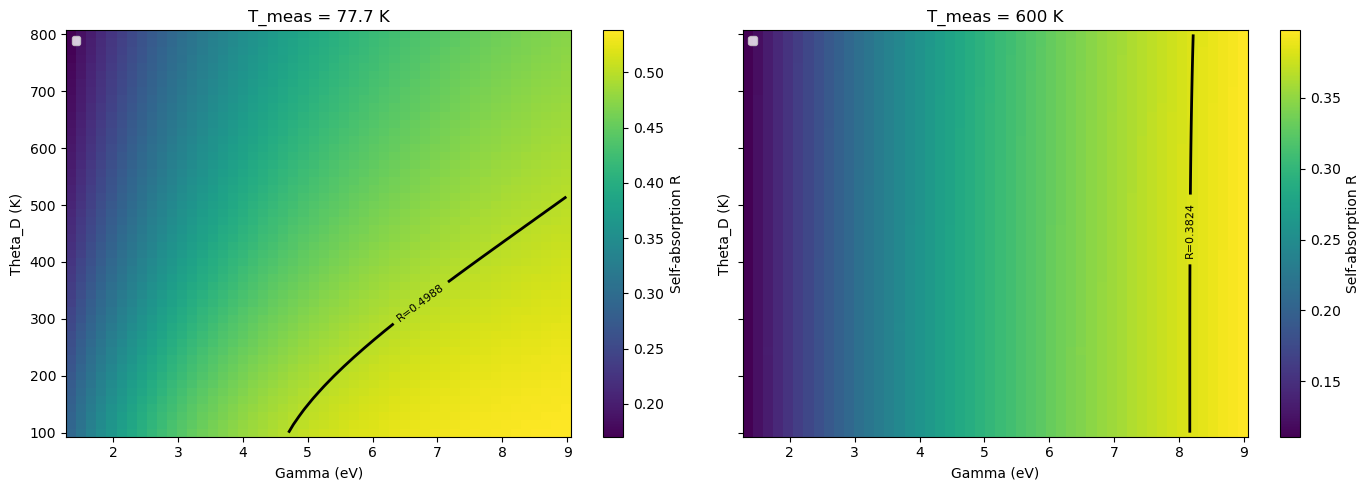

In [26]:
fig, axes = plt.subplots(1, len(Tmeas), figsize=(7 * len(Tmeas), 5), sharey=True)
if len(Tmeas) == 1:
    axes = [axes]

for ax, T_meas_val in zip(axes, Tmeas):
    im = ax.pcolormesh(Gamma_range_eV, theta_D_range, R_grid_TRSA_6Li[T_meas_val], shading="auto", cmap="viridis")
    R_level = R_self_absorption_TRSA_6Li[T_meas_val]
    contour = ax.contour(Gamma_range_eV, theta_D_range, R_grid_TRSA_6Li[T_meas_val], levels=[R_level], colors="black", linewidths=2)
    ax.clabel(contour, fmt=f"R={R_level:.4f}", fontsize=8)

    colorbar = fig.colorbar(im, ax=ax)
    colorbar.set_label("Self-absorption R")
    ax.set_xlabel("Gamma (eV)")
    ax.set_ylabel("Theta_D (K)")
    ax.set_title(f"T_meas = {T_meas_val} K")
    ax.legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

Intersection point(s):
Gamma = 8.1704 eV, Theta_D = 448.01 K


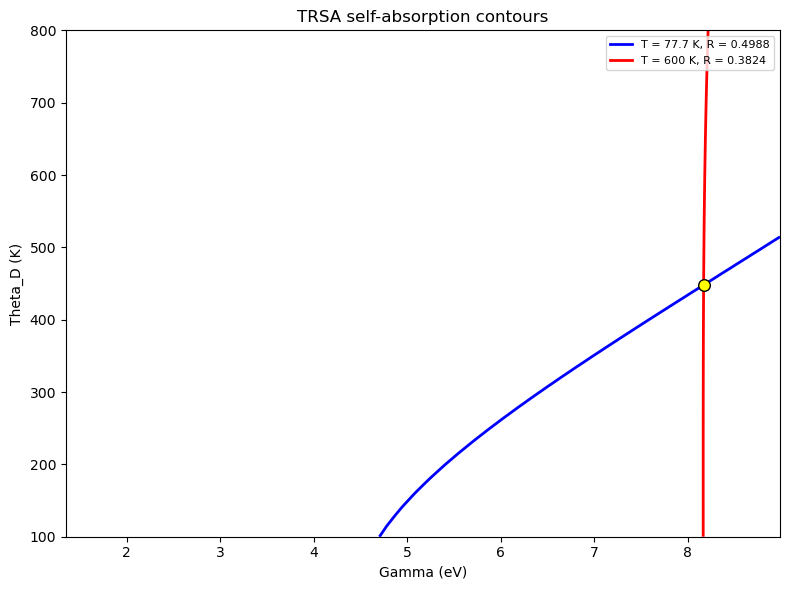

In [27]:
def get_contour_segments(contour_set):
    segments = []
    for level_segments in contour_set.allsegs:
        for segment in level_segments:
            if len(segment) > 1:
                segments.append(segment)
    return segments


def segment_intersection(point_a1, point_a2, point_b1, point_b2, tolerance=1e-12):
    x1, y1 = point_a1
    x2, y2 = point_a2
    x3, y3 = point_b1
    x4, y4 = point_b2

    denominator = (x1 - x2) * (y3 - y4) - (y1 - y2) * (x3 - x4)
    if abs(denominator) < tolerance:
        return None

    determinant_a = x1 * y2 - y1 * x2
    determinant_b = x3 * y4 - y3 * x4
    x_intersection = (determinant_a * (x3 - x4) - (x1 - x2) * determinant_b) / denominator
    y_intersection = (determinant_a * (y3 - y4) - (y1 - y2) * determinant_b) / denominator

    def within_segment(value, endpoint_1, endpoint_2):
        lower = min(endpoint_1, endpoint_2) - tolerance
        upper = max(endpoint_1, endpoint_2) + tolerance
        return lower <= value <= upper

    if (
        within_segment(x_intersection, x1, x2)
        and within_segment(y_intersection, y1, y2)
        and within_segment(x_intersection, x3, x4)
        and within_segment(y_intersection, y3, y4)
    ):
        return np.array([x_intersection, y_intersection])

    return None


def find_polyline_intersections(segments_a, segments_b):
    intersections = []
    for segment_a in segments_a:
        for segment_b in segments_b:
            for i in range(len(segment_a) - 1):
                for j in range(len(segment_b) - 1):
                    intersection = segment_intersection(
                        segment_a[i],
                        segment_a[i + 1],
                        segment_b[j],
                        segment_b[j + 1],
                    )
                    if intersection is not None:
                        intersections.append(intersection)

    if not intersections:
        return np.empty((0, 2))

    intersections = np.array(intersections)
    rounded = np.round(intersections, decimals=6)
    _, unique_indices = np.unique(rounded, axis=0, return_index=True)
    return intersections[np.sort(unique_indices)]


fig, ax = plt.subplots(figsize=(8, 6))
colors = ["blue", "red"]
contour_segments_by_temperature = {}
legend_handles = []

for color, T_meas_val in zip(colors, Tmeas):
    R_level = R_self_absorption_TRSA_6Li[T_meas_val]
    contour_set = ax.contour(
        Gamma_range_eV,
        theta_D_range,
        R_grid_TRSA_6Li[T_meas_val],
        levels=[R_level],
        colors=color,
        linewidths=2,
    )
    contour_segments_by_temperature[T_meas_val] = get_contour_segments(contour_set)
    legend_handles.append(
        plt.Line2D(
            [0],
            [0],
            color=color,
            lw=2,
            label=f"T = {T_meas_val} K, R = {R_level:.4f}",
        )
    )

intersection_points = np.empty((0, 2))
if len(Tmeas) >= 2:
    intersection_points = find_polyline_intersections(
        contour_segments_by_temperature[Tmeas[0]],
        contour_segments_by_temperature[Tmeas[1]],
    )

if len(intersection_points) > 0:
    ax.scatter(
        intersection_points[:, 0],
        intersection_points[:, 1],
        color="yellow",
        edgecolor="black",
        s=70,
        zorder=5,
        label="Intersection",
    )
    print("Intersection point(s):")
    for point in intersection_points:
        print(f"Gamma = {point[0]:.4f} eV, Theta_D = {point[1]:.2f} K")
else:
    print("No contour intersection found in the plotted domain.")


ax.set_xlabel("Gamma (eV)")
ax.set_ylabel("Theta_D (K)")
ax.set_title("TRSA self-absorption contours")
ax.legend(handles=legend_handles, loc="best", fontsize=8)
plt.tight_layout()
plt.show()

Surrogate RMS at T = 77.7 K: 2.276e-03
Surrogate RMS at T = 600 K: 2.263e-04
R_observed_dict was not defined; using the TRSA contour values with fallback uncertainties.


Initializing NUTS using jitter+adapt_diag...
/home/kprifti/miniconda3/envs/pymc_env/lib/python3.13/site-packages/pytensor/link/c/cmodule.py:2968: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [Gamma_eV, theta_D]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 3 seconds.


             mean       sd  hdi_15.95%  hdi_84.05%  mcse_mean  mcse_sd  \
Gamma_eV    8.182    0.058       8.126       8.243      0.001    0.001   
theta_D   445.431  103.938     344.844     547.932      1.563    1.476   

          ess_bulk  ess_tail  r_hat  
Gamma_eV    4587.0    4496.0    1.0  
theta_D     4466.0    3771.0    1.0  


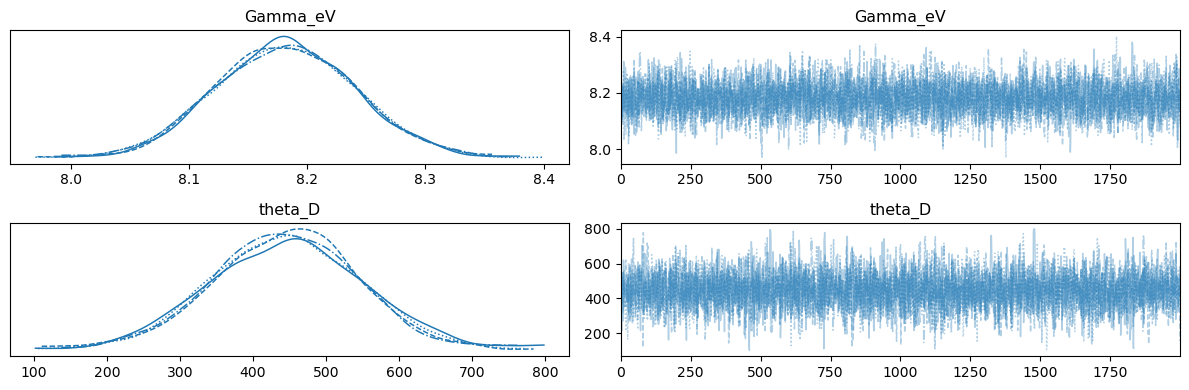

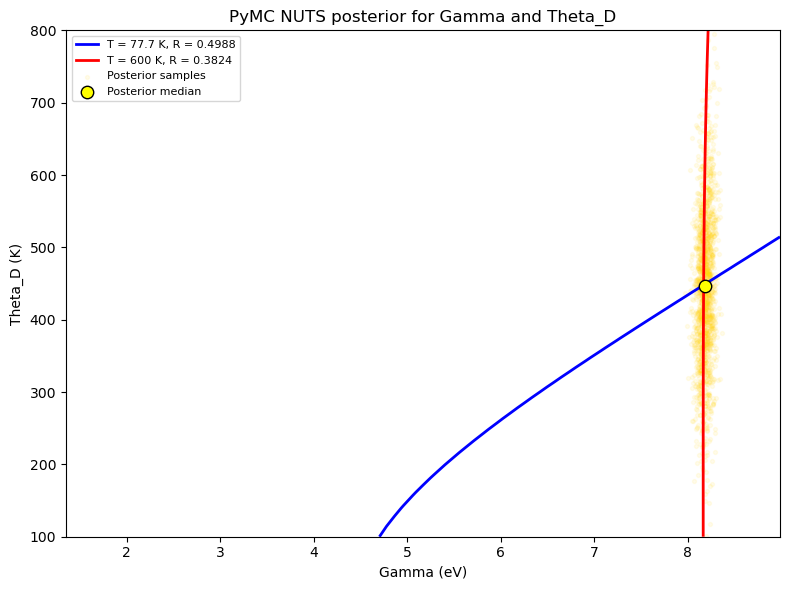

In [28]:
import pymc as pm
import pytensor.tensor as pt


def scaled_coordinate(value, lower, upper):
    return 2.0 * (value - lower) / (upper - lower) - 1.0


def polynomial_design_matrix(gamma_scaled, theta_scaled):
    return np.column_stack(
        [
            np.ones_like(gamma_scaled),
            gamma_scaled,
            theta_scaled,
            gamma_scaled**2,
            gamma_scaled * theta_scaled,
            theta_scaled**2,
            gamma_scaled**3,
            (gamma_scaled**2) * theta_scaled,
            gamma_scaled * (theta_scaled**2),
            theta_scaled**3,
        ]
    )


def fit_surrogate_coefficients(r_grid_values):
    gamma_mesh, theta_mesh = np.meshgrid(Gamma_range_eV, theta_D_range)
    gamma_scaled = scaled_coordinate(gamma_mesh.ravel(), gamma_min_eV, gamma_max_eV)
    theta_scaled = scaled_coordinate(theta_mesh.ravel(), theta_min_K, theta_max_K)
    design = polynomial_design_matrix(gamma_scaled, theta_scaled)
    coefficients, _, _, _ = np.linalg.lstsq(design, r_grid_values.ravel(), rcond=None)
    fitted = design @ coefficients
    rms_error = np.sqrt(np.mean((fitted - r_grid_values.ravel()) ** 2))
    return coefficients, rms_error


def surrogate_response(gamma_eV_value, theta_D_value, coefficients):
    gamma_scaled = scaled_coordinate(gamma_eV_value, gamma_min_eV, gamma_max_eV)
    theta_scaled = scaled_coordinate(theta_D_value, theta_min_K, theta_max_K)
    basis_terms = [
        pt.ones_like(gamma_scaled),
        gamma_scaled,
        theta_scaled,
        gamma_scaled**2,
        gamma_scaled * theta_scaled,
        theta_scaled**2,
        gamma_scaled**3,
        (gamma_scaled**2) * theta_scaled,
        gamma_scaled * (theta_scaled**2),
        theta_scaled**3,
    ]
    return sum(coefficient * term for coefficient, term in zip(coefficients, basis_terms))


gamma_min_eV = Gamma_range_eV.min()
gamma_max_eV = Gamma_range_eV.max()
theta_min_K = theta_D_range.min()
theta_max_K = theta_D_range.max()

surrogate_coefficients = {}
surrogate_rms = {}
for T_meas_val in Tmeas:
    coefficients, rms_error = fit_surrogate_coefficients(R_grid_TRSA_6Li[T_meas_val])
    surrogate_coefficients[T_meas_val] = coefficients
    surrogate_rms[T_meas_val] = rms_error
    print(f"Surrogate RMS at T = {T_meas_val} K: {rms_error:.3e}")

if "R_observed_dict" not in globals():
    R_observed_dict = {
        T_meas_val: ufloat(
            R_self_absorption_TRSA_6Li[T_meas_val],
            max(5.0 * surrogate_rms[T_meas_val], 1e-3),
        )
        for T_meas_val in Tmeas
    }
    print("R_observed_dict was not defined; using the TRSA contour values with fallback uncertainties.")

with pm.Model() as self_absorption_model:
    gamma_eV = pm.Uniform("Gamma_eV", lower=gamma_min_eV, upper=gamma_max_eV)
    theta_D = pm.Uniform("theta_D", lower=theta_min_K, upper=theta_max_K)

    for T_meas_val in Tmeas:
        predicted_R = pm.Deterministic(
            f"R_pred_{str(T_meas_val).replace('.', '_')}K",
            surrogate_response(gamma_eV, theta_D, surrogate_coefficients[T_meas_val]),
        )
        observed_R = R_observed_dict[T_meas_val]
        total_sigma = np.sqrt(observed_R.s**2 + surrogate_rms[T_meas_val] ** 2)
        pm.Normal(
            f"R_obs_{str(T_meas_val).replace('.', '_')}K",
            mu=predicted_R,
            sigma=total_sigma,
            observed=observed_R.n,
        )

    trace_nuts = pm.sample(
        draws=2000,
        tune=2000,
        chains=4,
        cores=2,
        target_accept=0.95,
        random_seed=42,
    )

posterior_summary = az.summary(trace_nuts, var_names=["Gamma_eV", "theta_D"], hdi_prob=0.681)
print(posterior_summary)

az.plot_trace(trace_nuts, var_names=["Gamma_eV", "theta_D"])
plt.tight_layout()
plt.show()

posterior_gamma = trace_nuts.posterior["Gamma_eV"].values.flatten()
posterior_theta = trace_nuts.posterior["theta_D"].values.flatten()

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["blue", "red"]
legend_handles = []
for color, T_meas_val in zip(colors, Tmeas):
    R_level = R_observed_dict[T_meas_val].n
    ax.contour(
        Gamma_range_eV,
        theta_D_range,
        R_grid_TRSA_6Li[T_meas_val],
        levels=[R_level],
        colors=color,
        linewidths=2,
    )
    legend_handles.append(
        plt.Line2D([0], [0], color=color, lw=2, label=f"T = {T_meas_val} K, R = {R_level:.4f}")
    )

sample_stride = max(len(posterior_gamma) // 1500, 1)
ax.scatter(
    posterior_gamma[::sample_stride],
    posterior_theta[::sample_stride],
    s=8,
    alpha=0.08,
    color="gold",
    label="Posterior samples",
)

posterior_gamma_median = np.median(posterior_gamma)
posterior_theta_median = np.median(posterior_theta)
ax.scatter(
    posterior_gamma_median,
    posterior_theta_median,
    color="yellow",
    edgecolor="black",
    s=80,
    zorder=5,
    label="Posterior median",
)

ax.set_xlabel("Gamma (eV)")
ax.set_ylabel("Theta_D (K)")
ax.set_title("PyMC NUTS posterior for Gamma and Theta_D")
ax.legend(handles=legend_handles + ax.collections[-2:], loc="best", fontsize=8)
plt.tight_layout()
plt.show()

T = 77.7 K: R = 0.498807 ± 0.000704
T = 600 K: R = 0.382363 ± 0.000811


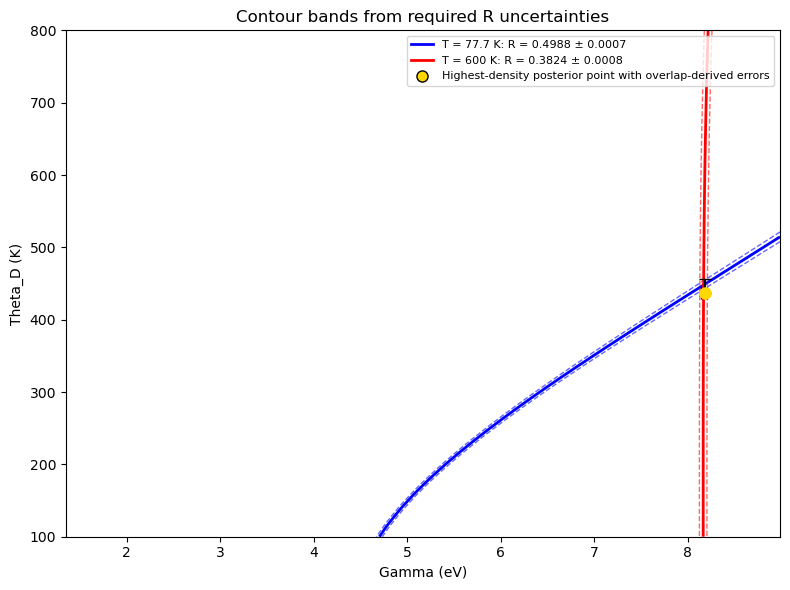

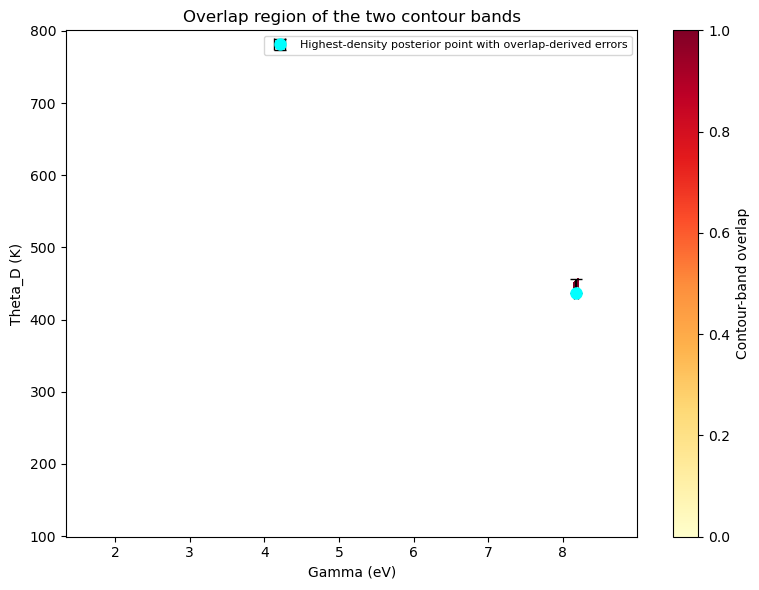

In [29]:
from scipy.interpolate import RegularGridInterpolator
from scipy.stats import gaussian_kde

def finite_difference_gradient(interpolator, gamma_eV_value, theta_D_value, gamma_step, theta_step):
    gamma_plus = min(gamma_eV_value + gamma_step, gamma_max_eV)
    gamma_minus = max(gamma_eV_value - gamma_step, gamma_min_eV)
    theta_plus = min(theta_D_value + theta_step, theta_max_K)
    theta_minus = max(theta_D_value - theta_step, theta_min_K)

    dR_dGamma = (
        float(interpolator((theta_D_value, gamma_plus)))
        - float(interpolator((theta_D_value, gamma_minus)))
    ) / (gamma_plus - gamma_minus)
    dR_dTheta = (
        float(interpolator((theta_plus, gamma_eV_value)))
        - float(interpolator((theta_minus, gamma_eV_value)))
    ) / (theta_plus - theta_minus)
    return dR_dGamma, dR_dTheta


def highest_density_point(x_samples, y_samples):
    stacked = np.vstack([x_samples, y_samples])
    density = gaussian_kde(stacked)(stacked)
    max_index = np.argmax(density)
    return x_samples[max_index], y_samples[max_index]


target_gamma_relative_uncertainty = 0.005
mode_gamma_eV, mode_theta_D = highest_density_point(posterior_gamma, posterior_theta)

gamma_step_eV = float(np.diff(Gamma_range_eV).mean())
theta_step_K = float(np.diff(theta_D_range).mean())

interpolators = {
    T_meas_val: RegularGridInterpolator(
        (theta_D_range, Gamma_range_eV),
        R_grid_TRSA_6Li[T_meas_val],
        bounds_error=False,
        fill_value=None,
    )
    for T_meas_val in Tmeas
}

jacobian_rows = []
count_variance_factors = []
nominal_R_values = {}
for T_meas_val in Tmeas:
    dR_dGamma, dR_dTheta = finite_difference_gradient(
        interpolators[T_meas_val],
        mode_gamma_eV,
        mode_theta_D,
        gamma_step_eV,
        theta_step_K,
    )
    jacobian_rows.append([dR_dGamma, dR_dTheta])

    nominal_R = R_observed_dict[T_meas_val].n if T_meas_val in R_observed_dict else float(interpolators[T_meas_val]((mode_theta_D, mode_gamma_eV)))
    nominal_R_values[T_meas_val] = nominal_R
    count_variance_factors.append((1.0 - nominal_R) * (2.0 - nominal_R))

jacobian = np.array(jacobian_rows, dtype=float)
count_variance_factors = np.array(count_variance_factors, dtype=float)
weighted_information_per_no_absorber_count = jacobian.T @ np.diag(1.0 / count_variance_factors) @ jacobian
covariance_per_single_no_absorber_count = np.linalg.inv(weighted_information_per_no_absorber_count)

required_no_absorber_counts = float(
    covariance_per_single_no_absorber_count[0, 0]
    / (target_gamma_relative_uncertainty**2 * mode_gamma_eV**2)
)
required_R_sigmas = np.sqrt(count_variance_factors / required_no_absorber_counts)
required_R_uncertainty_dict = {
    T_meas_val: required_R_sigmas[index]
    for index, T_meas_val in enumerate(Tmeas)
}

for T_meas_val in Tmeas:
    print(f"T = {T_meas_val} K: R = {nominal_R_values[T_meas_val]:.6f} ± {required_R_uncertainty_dict[T_meas_val]:.6f}")

fine_gamma_eV = np.linspace(Gamma_range_eV.min(), Gamma_range_eV.max(), 400)
fine_theta_K = np.linspace(theta_D_range.min(), theta_D_range.max(), 400)
fine_gamma_mesh_eV, fine_theta_mesh_K = np.meshgrid(fine_gamma_eV, fine_theta_K)
fine_points = np.column_stack([fine_theta_mesh_K.ravel(), fine_gamma_mesh_eV.ravel()])

overlap_mask_fine = np.ones(fine_gamma_mesh_eV.shape, dtype=bool)
for T_meas_val in Tmeas:
    interpolated_grid = interpolators[T_meas_val](fine_points).reshape(fine_gamma_mesh_eV.shape)
    overlap_mask_fine &= np.abs(interpolated_grid - nominal_R_values[T_meas_val]) <= required_R_uncertainty_dict[T_meas_val]

if overlap_mask_fine.any():
    overlap_gamma_values = fine_gamma_mesh_eV[overlap_mask_fine]
    overlap_theta_values = fine_theta_mesh_K[overlap_mask_fine]
    gamma_xerr = np.array([
        [max(mode_gamma_eV - overlap_gamma_values.min(), 0.0)],
        [max(overlap_gamma_values.max() - mode_gamma_eV, 0.0)],
    ])
    theta_yerr = np.array([
        [max(mode_theta_D - overlap_theta_values.min(), 0.0)],
        [max(overlap_theta_values.max() - mode_theta_D, 0.0)],
    ])
else:
    gamma_xerr = np.array([[0.0], [0.0]])
    theta_yerr = np.array([[0.0], [0.0]])

overlap_map = np.where(overlap_mask_fine, 1.0, np.nan)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["blue", "red"]
legend_handles = []
for color, T_meas_val in zip(colors, Tmeas):
    R_center = nominal_R_values[T_meas_val]
    sigma_R = required_R_uncertainty_dict[T_meas_val]

    ax.contour(
        Gamma_range_eV,
        theta_D_range,
        R_grid_TRSA_6Li[T_meas_val],
        levels=[R_center],
        colors=color,
        linewidths=2,
    )
    ax.contour(
        Gamma_range_eV,
        theta_D_range,
        R_grid_TRSA_6Li[T_meas_val],
        levels=[R_center - sigma_R, R_center + sigma_R],
        colors=color,
        linewidths=1,
        linestyles="--",
        alpha=0.6,
    )
    legend_handles.append(
        plt.Line2D(
            [0],
            [0],
            color=color,
            lw=2,
            label=f"T = {T_meas_val} K: R = {R_center:.4f} ± {sigma_R:.4f}",
        )
    )

ax.errorbar(
    mode_gamma_eV,
    mode_theta_D,
    xerr=gamma_xerr,
    yerr=theta_yerr,
    fmt="o",
    color="gold",
    ecolor="black",
    elinewidth=1.5,
    capsize=4,
    markersize=8,
)
legend_handles.append(
    plt.Line2D([0], [0], marker="o", color="gold", markeredgecolor="black", lw=0, markersize=8, label="Highest-density posterior point with overlap-derived errors")
)

ax.set_xlabel("Gamma (eV)")
ax.set_ylabel("Theta_D (K)")
ax.set_title("Contour bands from required R uncertainties")
ax.legend(handles=legend_handles, loc="best", fontsize=8)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.pcolormesh(
    fine_gamma_eV,
    fine_theta_K,
    overlap_map,
    shading="auto",
    cmap="YlOrRd",
    vmin=0.0,
    vmax=1.0,
)

ax.errorbar(
    mode_gamma_eV,
    mode_theta_D,
    xerr=gamma_xerr,
    yerr=theta_yerr,
    fmt="o",
    color="cyan",
    ecolor="black",
    elinewidth=1.5,
    capsize=4,
    markersize=8,
    label="Highest-density posterior point with overlap-derived errors",
)

colorbar = fig.colorbar(im, ax=ax)
colorbar.set_label("Contour-band overlap")
ax.set_xlabel("Gamma (eV)")
ax.set_ylabel("Theta_D (K)")
ax.set_title("Overlap region of the two contour bands")
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

In [30]:
import pymc as pm
import pytensor.tensor as pt


def bilinear_interpolate_regular_grid(gamma_eV_value, theta_D_value, gamma_axis, theta_axis, grid_values):
    gamma_min = float(gamma_axis[0])
    gamma_step = float(gamma_axis[1] - gamma_axis[0])
    theta_min = float(theta_axis[0])
    theta_step = float(theta_axis[1] - theta_axis[0])

    gamma_position = (gamma_eV_value - gamma_min) / gamma_step
    theta_position = (theta_D_value - theta_min) / theta_step

    gamma_index_low = pt.cast(pt.floor(gamma_position), "int32")
    theta_index_low = pt.cast(pt.floor(theta_position), "int32")

    gamma_index_low = pt.clip(gamma_index_low, 0, len(gamma_axis) - 2)
    theta_index_low = pt.clip(theta_index_low, 0, len(theta_axis) - 2)

    gamma_index_high = gamma_index_low + 1
    theta_index_high = theta_index_low + 1

    gamma_fraction = gamma_position - pt.cast(gamma_index_low, gamma_position.dtype)
    theta_fraction = theta_position - pt.cast(theta_index_low, theta_position.dtype)

    z00 = grid_values[theta_index_low, gamma_index_low]
    z10 = grid_values[theta_index_low, gamma_index_high]
    z01 = grid_values[theta_index_high, gamma_index_low]
    z11 = grid_values[theta_index_high, gamma_index_high]

    return (
        (1.0 - gamma_fraction) * (1.0 - theta_fraction) * z00
        + gamma_fraction * (1.0 - theta_fraction) * z10
        + (1.0 - gamma_fraction) * theta_fraction * z01
        + gamma_fraction * theta_fraction * z11
    )


gamma_axis_eV = Gamma_range_eV.astype(float)
theta_axis_K = theta_D_range.astype(float)
grid_tensors = {
    T_meas_val: pt.as_tensor_variable(np.asarray(R_grid_TRSA_6Li[T_meas_val], dtype=float))
    for T_meas_val in Tmeas
}

R_observed_bilinear_dict = {
    T_meas_val: ufloat(nominal_R_values[T_meas_val], required_R_uncertainty_dict[T_meas_val])
    for T_meas_val in Tmeas
}

with pm.Model() as bilinear_self_absorption_model:
    gamma_eV_bilinear = pm.Uniform("Gamma_eV", lower=float(gamma_axis_eV.min()), upper=float(gamma_axis_eV.max()))
    theta_D_bilinear = pm.Uniform("theta_D", lower=float(theta_axis_K.min()), upper=float(theta_axis_K.max()))

    for T_meas_val in Tmeas:
        predicted_R = pm.Deterministic(
            f"R_pred_{str(T_meas_val).replace('.', '_')}K_bilinear",
            bilinear_interpolate_regular_grid(
                gamma_eV_bilinear,
                theta_D_bilinear,
                gamma_axis_eV,
                theta_axis_K,
                grid_tensors[T_meas_val],
            ),
        )
        pm.Normal(
            f"R_obs_{str(T_meas_val).replace('.', '_')}K_bilinear",
            mu=predicted_R,
            sigma=R_observed_bilinear_dict[T_meas_val].s,
            observed=R_observed_bilinear_dict[T_meas_val].n,
        )

    bilinear_trace_nuts = pm.sample(
        draws=2000,
        tune=2000,
        chains=4,
        cores=2,
        target_accept=0.95,
        random_seed=42,
    )

posterior_gamma_bilinear = bilinear_trace_nuts.posterior["Gamma_eV"].values.flatten()
posterior_theta_bilinear = bilinear_trace_nuts.posterior["theta_D"].values.flatten()
mode_gamma_bilinear, mode_theta_bilinear = highest_density_point(
    posterior_gamma_bilinear,
    posterior_theta_bilinear,
)

print(f"Gamma = {mode_gamma_bilinear:.4f} eV")
print(f"theta_D = {mode_theta_bilinear:.2f} K")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [Gamma_eV, theta_D]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 3 seconds.


Gamma = 8.1754 eV
theta_D = 448.40 K


array([[<Axes: title={'center': 'Gamma_eV'}>,
        <Axes: title={'center': 'Gamma_eV'}>],
       [<Axes: title={'center': 'theta_D'}>,
        <Axes: title={'center': 'theta_D'}>]], dtype=object)

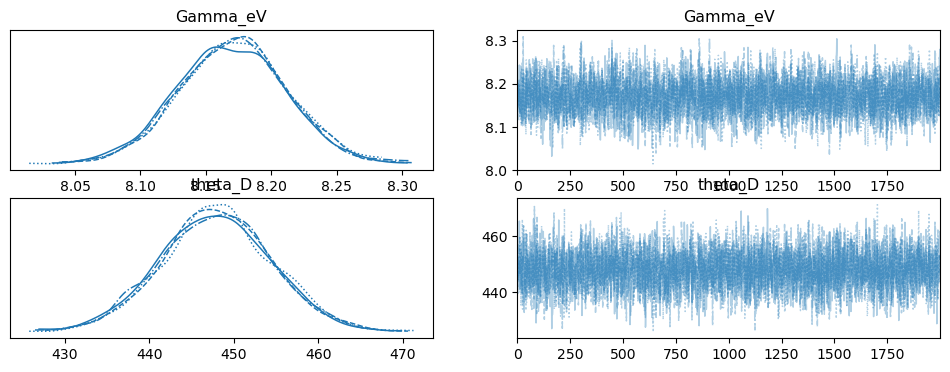

In [31]:
az.plot_trace(bilinear_trace_nuts, var_names=["Gamma_eV", "theta_D"])


In [32]:
az.summary(bilinear_trace_nuts, var_names=["Gamma_eV", "theta_D"], hdi_prob=0.681)

,mean,sd,hdi_15.95%,hdi_84.05%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Gamma_eV,8.171,0.041,8.127,8.208,0.001,0.000,2927.0,3667.0,1.0
theta_D,447.945,6.537,441.319,454.261,0.112,0.071,3438.0,4558.0,1.0


In [33]:
R_exp_77K = ufloat(0.498807, 0.000704)
R_exp_600K = ufloat(0.382363, 0.000811)

In [151]:
duration_days = 8  # measurement duration without absorber
duration_NRF_li6 = duration_days * 24 * 3600 # in seconds

In [167]:
# Sampling directly from the experimental definition:
# Rexp = 1 - N_with_absorber / N_without_absorber

ref_duration_s = duration_NRF_li6  # current reference duration in seconds
reference_duration_days = ref_duration_s / 3600 / 24
current_total_expected_peak_counts = (
    expected_peak_counts_HPGe2 + expected_peak_counts_HPGePol
) * ref_duration_s

chain_count = 4
draws_per_chain = 10000
hdi_prob = 0.681
sample_shape = (chain_count, draws_per_chain)
rng = np.random.default_rng(123)

def draw_truncated_normal(mu, sigma, lower, upper, size, random_generator):
    if sigma <= 0:
        return np.full(size, mu, dtype=float)
    a = (lower - mu) / sigma
    b = (upper - mu) / sigma
    return truncnorm.rvs(a, b, loc=mu, scale=sigma, size=size, random_state=random_generator)

N_without_absorber_samples = draw_truncated_normal(
    current_total_expected_peak_counts.n,
    current_total_expected_peak_counts.s,
    lower=0.0,
    upper=np.inf,
    size=sample_shape,
    random_generator=rng,
)
rate_without_absorber_samples = N_without_absorber_samples / ref_duration_s

Rexp_by_temperature = {
    77.7: R_exp_77K,
    600.0: R_exp_600K,
}

duration_results_by_temperature = {}
for temperature_value, Rexp_value in Rexp_by_temperature.items():
    Rexp_samples = draw_truncated_normal(
        Rexp_value.n,
        Rexp_value.s,
        lower=0.0,
        upper=1.0,
        size=sample_shape,
        random_generator=rng,
    )

    attenuation_factor_samples = 1.0 - Rexp_samples
    N_with_absorber_samples = N_without_absorber_samples * attenuation_factor_samples
    rate_with_absorber_samples = N_with_absorber_samples / ref_duration_s
    duration_for_equal_statistics_s = N_without_absorber_samples / rate_with_absorber_samples
    duration_for_equal_statistics_days = duration_for_equal_statistics_s / 3600 / 24

    duration_results_by_temperature[temperature_value] = {
        "R": Rexp_value,
        "rate_without_absorber_median": np.median(rate_without_absorber_samples),
        "rate_with_absorber_median": np.median(rate_with_absorber_samples),
        "duration_days_samples": duration_for_equal_statistics_days,
        "duration_days_hdi": az.hdi(duration_for_equal_statistics_days.reshape(-1), hdi_prob=hdi_prob),
        "duration_days_median": np.median(duration_for_equal_statistics_days),
    }

print(
    f"Using duration_days = {reference_duration_days:.2f} d gives "
    f"{current_total_expected_peak_counts.n:.0f} ± {current_total_expected_peak_counts.s:.0f} expected counts without absorber."
)

Using duration_days = 8.00 d gives 113462 ± 5223 expected counts without absorber.


In [168]:
duration_without_absorber_days = ref_duration_s / 3600 / 24

duration_results_table = pd.DataFrame(
    [
        {
            "T_meas (K)": temperature_value,
            "R_exp": duration_results_by_temperature[temperature_value]["R"].n,
            "sigma_R": duration_results_by_temperature[temperature_value]["R"].s,
            "Rate without absorber (counts/s)": duration_results_by_temperature[temperature_value]["rate_without_absorber_median"],
            "Rate with absorber (counts/s)": duration_results_by_temperature[temperature_value]["rate_with_absorber_median"],
            "Duration without absorber (days)": duration_without_absorber_days,
            "Median duration with absorber (days)": duration_results_by_temperature[temperature_value]["duration_days_median"],
            f"{hdi_prob:.1%} HDI with absorber (days)": (
                f"[{duration_results_by_temperature[temperature_value]['duration_days_hdi'][0]:.4f}, "
                f"{duration_results_by_temperature[temperature_value]['duration_days_hdi'][1]:.4f}]"
            ),
        }
        for temperature_value in sorted(duration_results_by_temperature)
    ]
)

duration_results_table["R_exp"] = duration_results_table["R_exp"].map(lambda value: f"{value:.6f}")
duration_results_table["sigma_R"] = duration_results_table["sigma_R"].map(lambda value: f"{value:.6f}")
duration_results_table["Rate without absorber (counts/s)"] = duration_results_table["Rate without absorber (counts/s)"].map(lambda value: f"{value:.4f}")
duration_results_table["Rate with absorber (counts/s)"] = duration_results_table["Rate with absorber (counts/s)"].map(lambda value: f"{value:.4f}")
duration_results_table["Duration without absorber (days)"] = duration_results_table["Duration without absorber (days)"].map(lambda value: f"{value:.4f}")
duration_results_table["Median duration with absorber (days)"] = duration_results_table["Median duration with absorber (days)"].map(lambda value: f"{value:.4f}")

display(duration_results_table)

,T_meas (K),R_exp,sigma_R,Rate without absorber (counts/s),Rate with absorber (counts/s),Duration without absorber (days),Median duration with absorber (days),68.1% HDI with absorber (days)
0,77.7,0.498807,0.000704,0.1641,0.0823,8.0000,15.9620,"[15.9401, 15.9845]"
1,600.0,0.382363,0.000811,0.1641,0.1014,8.0000,12.9526,"[12.9357, 12.9695]"


,T_meas (K),Scenario,Peak volume from fit (counts),Area uncertainty from fit (counts),Gaussian sigma (keV),FWHM (keV)
0,77.7,Without absorber,113428,336.8,1.413,3.327
1,77.7,With absorber,56847,238.4,1.415,3.332
2,600.0,Without absorber,113428,336.8,1.413,3.327
3,600.0,With absorber,70051,264.7,1.409,3.318


,T_meas (K),R from fitted areas,sigma_R from fitted areas,Required sigma_R for 0.5% Gamma,Achieved / required sigma_R,Meets 0.5% Gamma target
0,77.7,0.498829,0.002575,0.000704,3.66,No
1,600.0,0.382421,0.002968,0.000811,3.66,No


Using measurement duration: 8.00 d
Assumed input FWHM for histogram generation: 3.30 keV
The Gaussian sigma is the fitted width in energy. The self-absorption precision must be computed from the ratio R = 1 - N_with / N_without, using the fitted peak-area uncertainties.


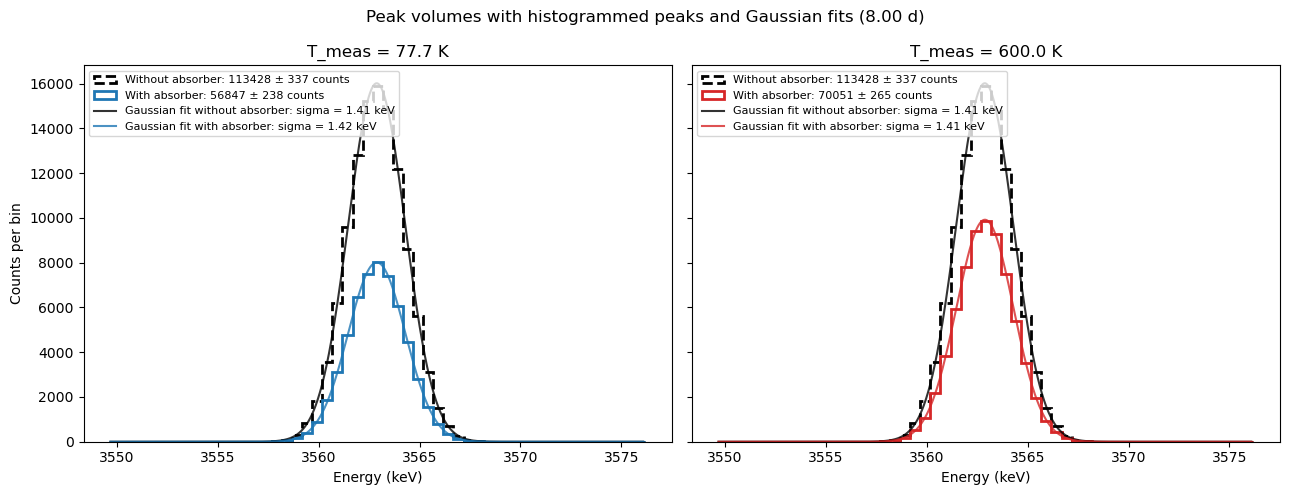

In [170]:
from scipy.optimize import curve_fit

excitation_energy_keV = 1e3 * li6.excited_states["0^+_1"].excitation_energy
assumed_fwhm_keV = 3.3
peak_sigma_keV = assumed_fwhm_keV / (2.0 * np.sqrt(2.0 * np.log(2.0)))
plot_duration_days = ref_duration_s / 3600 / 24

energy_min_keV = excitation_energy_keV - 4.0 * assumed_fwhm_keV
energy_max_keV = excitation_energy_keV + 4.0 * assumed_fwhm_keV
bin_width_keV = 0.5
histogram_bins = np.arange(energy_min_keV, energy_max_keV + bin_width_keV, bin_width_keV)
fit_energy_axis = np.linspace(energy_min_keV, energy_max_keV, 1200)


def gaussian_counts_per_bin(energy_keV, amplitude, centroid_keV, sigma_keV):
    return amplitude * np.exp(-0.5 * ((energy_keV - centroid_keV) / sigma_keV) ** 2)


def fit_histogram_peak(event_energies):
    counts, edges = np.histogram(event_energies, bins=histogram_bins)
    centers = 0.5 * (edges[:-1] + edges[1:])
    count_uncertainties = np.sqrt(np.clip(counts.astype(float), 1.0, None))
    parameters, covariance = curve_fit(
        gaussian_counts_per_bin,
        centers,
        counts,
        sigma=count_uncertainties,
        absolute_sigma=True,
        p0=[counts.max(), excitation_energy_keV, peak_sigma_keV],
        bounds=([0.0, energy_min_keV, 0.1], [np.inf, energy_max_keV, 10.0]),
    )

    amplitude, centroid_keV, sigma_keV_fit = parameters
    sigma_keV_fit_uncertainty = np.sqrt(max(covariance[2, 2], 0.0))
    centroid_keV_uncertainty = np.sqrt(max(covariance[1, 1], 0.0))

    area_conversion = np.sqrt(2.0 * np.pi) / bin_width_keV
    fitted_area_counts = amplitude * sigma_keV_fit * area_conversion
    derivative_amplitude = sigma_keV_fit * area_conversion
    derivative_sigma = amplitude * area_conversion
    area_variance = (
        derivative_amplitude**2 * covariance[0, 0]
        + derivative_sigma**2 * covariance[2, 2]
        + 2.0 * derivative_amplitude * derivative_sigma * covariance[0, 2]
    )
    fitted_area_uncertainty = np.sqrt(max(area_variance, 0.0))

    fitted_fwhm_keV = 2.0 * np.sqrt(2.0 * np.log(2.0)) * sigma_keV_fit
    fitted_fwhm_uncertainty_keV = 2.0 * np.sqrt(2.0 * np.log(2.0)) * sigma_keV_fit_uncertainty

    return {
        "counts": counts,
        "edges": edges,
        "centers": centers,
        "parameters": parameters,
        "covariance": covariance,
        "fitted_area": ufloat(fitted_area_counts, fitted_area_uncertainty),
        "centroid": ufloat(centroid_keV, centroid_keV_uncertainty),
        "sigma_keV": ufloat(sigma_keV_fit, sigma_keV_fit_uncertainty),
        "fwhm_keV": ufloat(fitted_fwhm_keV, fitted_fwhm_uncertainty_keV),
    }


nominal_no_absorber_counts = float(np.median(N_without_absorber_samples.reshape(-1)))
rng_without = np.random.default_rng(2000)
without_event_energies = rng_without.normal(
    loc=excitation_energy_keV,
    scale=peak_sigma_keV,
    size=int(round(nominal_no_absorber_counts)),
)
without_fit_result = fit_histogram_peak(without_event_energies)

peak_volume_summary = {
    "without_absorber": without_fit_result["fitted_area"],
    "with_absorber": {},
}
peak_shape_summary = {"without_absorber": without_fit_result, "with_absorber": {}}

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
colors = {"without": "black", 77.7: "tab:blue", 600.0: "tab:red"}
summary_rows = []
self_absorption_rows = []

for ax, temperature_value in zip(axes, sorted(Rexp_by_temperature)):
    nominal_with_absorber_counts = float(
        np.median(N_without_absorber_samples * (1.0 - Rexp_by_temperature[temperature_value].n))
    )
    rng_with = np.random.default_rng(3000 + int(round(10.0 * temperature_value)))
    with_event_energies = rng_with.normal(
        loc=excitation_energy_keV,
        scale=peak_sigma_keV,
        size=int(round(nominal_with_absorber_counts)),
    )
    with_fit_result = fit_histogram_peak(with_event_energies)

    peak_volume_summary["with_absorber"][temperature_value] = with_fit_result["fitted_area"]
    peak_shape_summary["with_absorber"][temperature_value] = with_fit_result

    fitted_R = 1.0 - with_fit_result["fitted_area"] / without_fit_result["fitted_area"]
    target_sigma_R = required_R_uncertainty_dict[temperature_value]
    sigma_ratio = fitted_R.s / target_sigma_R if target_sigma_R > 0 else np.nan

    summary_rows.append(
        {
            "T_meas (K)": temperature_value,
            "Scenario": "Without absorber",
            "Peak volume from fit (counts)": without_fit_result["fitted_area"].n,
            "Area uncertainty from fit (counts)": without_fit_result["fitted_area"].s,
            "Gaussian sigma (keV)": without_fit_result["sigma_keV"].n,
            "FWHM (keV)": without_fit_result["fwhm_keV"].n,
        }
    )
    summary_rows.append(
        {
            "T_meas (K)": temperature_value,
            "Scenario": "With absorber",
            "Peak volume from fit (counts)": with_fit_result["fitted_area"].n,
            "Area uncertainty from fit (counts)": with_fit_result["fitted_area"].s,
            "Gaussian sigma (keV)": with_fit_result["sigma_keV"].n,
            "FWHM (keV)": with_fit_result["fwhm_keV"].n,
        }
    )
    self_absorption_rows.append(
        {
            "T_meas (K)": temperature_value,
            "R from fitted areas": fitted_R.n,
            "sigma_R from fitted areas": fitted_R.s,
            "Required sigma_R for 0.5% Gamma": target_sigma_R,
            "Achieved / required sigma_R": sigma_ratio,
            "Meets 0.5% Gamma target": "Yes" if fitted_R.s <= target_sigma_R else "No",
        }
    )

    ax.hist(
        without_event_energies,
        bins=histogram_bins,
        histtype="step",
        linewidth=2,
        linestyle="--",
        color=colors["without"],
        label=(
            f"Without absorber: {without_fit_result['fitted_area'].n:.0f} "
            f"± {without_fit_result['fitted_area'].s:.0f} counts"
        ),
    )
    ax.hist(
        with_event_energies,
        bins=histogram_bins,
        histtype="step",
        linewidth=2,
        color=colors[temperature_value],
        label=(
            f"With absorber: {with_fit_result['fitted_area'].n:.0f} "
            f"± {with_fit_result['fitted_area'].s:.0f} counts"
        ),
    )

    ax.plot(
        fit_energy_axis,
        gaussian_counts_per_bin(fit_energy_axis, *without_fit_result["parameters"]),
        color=colors["without"],
        linewidth=1.5,
        alpha=0.8,
        label=(
            f"Gaussian fit without absorber: "
            f"sigma = {without_fit_result['sigma_keV'].n:.2f} keV"
        ),
    )
    ax.plot(
        fit_energy_axis,
        gaussian_counts_per_bin(fit_energy_axis, *with_fit_result["parameters"]),
        color=colors[temperature_value],
        linewidth=1.5,
        alpha=0.8,
        label=(
            f"Gaussian fit with absorber: "
            f"sigma = {with_fit_result['sigma_keV'].n:.2f} keV"
        ),
    )

    ax.set_title(f"T_meas = {temperature_value} K")
    ax.set_xlabel("Energy (keV)")
    ax.legend(loc="upper left", fontsize=8)

peak_volume_table = pd.DataFrame(summary_rows)
peak_volume_table["Peak volume from fit (counts)"] = peak_volume_table["Peak volume from fit (counts)"].map(lambda value: f"{value:.0f}")
peak_volume_table["Area uncertainty from fit (counts)"] = peak_volume_table["Area uncertainty from fit (counts)"].map(lambda value: f"{value:.1f}")
peak_volume_table["Gaussian sigma (keV)"] = peak_volume_table["Gaussian sigma (keV)"].map(lambda value: f"{value:.3f}")
peak_volume_table["FWHM (keV)"] = peak_volume_table["FWHM (keV)"].map(lambda value: f"{value:.3f}")

display(peak_volume_table)

self_absorption_from_fit_table = pd.DataFrame(self_absorption_rows)
self_absorption_from_fit_table["R from fitted areas"] = self_absorption_from_fit_table["R from fitted areas"].map(lambda value: f"{value:.6f}")
self_absorption_from_fit_table["sigma_R from fitted areas"] = self_absorption_from_fit_table["sigma_R from fitted areas"].map(lambda value: f"{value:.6f}")
self_absorption_from_fit_table["Required sigma_R for 0.5% Gamma"] = self_absorption_from_fit_table["Required sigma_R for 0.5% Gamma"].map(lambda value: f"{value:.6f}")
self_absorption_from_fit_table["Achieved / required sigma_R"] = self_absorption_from_fit_table["Achieved / required sigma_R"].map(lambda value: f"{value:.2f}")
display(self_absorption_from_fit_table)

print(f"Using measurement duration: {plot_duration_days:.2f} d")
print(f"Assumed input FWHM for histogram generation: {assumed_fwhm_keV:.2f} keV")
print("The Gaussian sigma is the fitted width in energy. The self-absorption precision must be computed from the ratio R = 1 - N_with / N_without, using the fitted peak-area uncertainties.")

axes[0].set_ylabel("Counts per bin")
fig.suptitle(f"Peak volumes with histogrammed peaks and Gaussian fits ({plot_duration_days:.2f} d)")
plt.tight_layout()
plt.show()

In [172]:
#TODO: something is wrong with the uncertainty of the peak volumes. Which means i get wrong estimation for the self absorption and as a results the precision of Gamma. Check that and fix the durations